# Individual SMAC-seed fixed-depth trajectories

Best-so-far regret versus completed SMAC trials for benchmark seeds **42** and **46**. Each panel contains one individual SMAC seed and compares fixed depths **5, 10, 15, 20, 26, 32, 41, 50**.

Depths 5/10/15/20 are loaded from `01_15d_20_instances`; depths 26/32/41/50 are loaded from `01_02_15d_20_instances`. The underlying result files are referenced directly and are not copied.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')

RELATIVE_ANALYSIS_DIR = Path('experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_03_individual_smac_sees')
ANALYSIS_DIR = RELATIVE_ANALYSIS_DIR if RELATIVE_ANALYSIS_DIR.exists() else Path.cwd()
EXPERIMENT_ROOT = ANALYSIS_DIR.parent
ORIGINAL_OUTPUT = EXPERIMENT_ROOT / '01_15d_20_instances' / 'smac_output'
FOLLOWUP_OUTPUT = EXPERIMENT_ROOT / '01_02_15d_20_instances' / 'smac_output'
PLOT_DIR = ANALYSIS_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

BENCHMARK_SEEDS = (42, 46)
SMAC_SEEDS = tuple(range(6))
DEPTHS = (5, 10, 15, 20, 26, 32, 41, 50)
ORIGINAL_DEPTHS = frozenset((5, 10, 15, 20))
N_TRIALS = 3500
COLORS = dict(zip(DEPTHS, sns.color_palette('colorblind', n_colors=len(DEPTHS))))

print('Analysis directory:', ANALYSIS_DIR.resolve())
print('Plots will be saved to:', PLOT_DIR.resolve())

Analysis directory: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_03_individual_smac_sees
Plots will be saved to: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_03_individual_smac_sees/plots


## Load and validate all requested runs

A trajectory is accepted only when its metadata matches the requested benchmark seed, SMAC seed, and fixed-depth policy, and when it contains a finite, monotone 3,500-trial best-so-far regret sequence.

In [2]:
records = []
problems = []

for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in SMAC_SEEDS:
        for depth in DEPTHS:
            source_output = ORIGINAL_OUTPUT if depth in ORIGINAL_DEPTHS else FOLLOWUP_OUTPUT
            source_name = '01_15d_20_instances' if depth in ORIGINAL_DEPTHS else '01_02_15d_20_instances'
            policy = f'fixed_depth_{depth}'
            path = source_output / f'benchmark_seed_{benchmark_seed}' / policy / str(smac_seed) / 'trajectory.json'

            try:
                data = json.loads(path.read_text())
                trajectory = np.asarray(data['best_regret'], dtype=float)
            except (OSError, json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
                problems.append((benchmark_seed, smac_seed, depth, str(error), str(path)))
                continue

            checks = {
                'benchmark seed': data.get('benchmark_seed') == benchmark_seed,
                'SMAC seed': data.get('smac_seed') == smac_seed,
                'policy': data.get('policy') == policy,
                'length': len(trajectory) == N_TRIALS,
                'finite': bool(np.isfinite(trajectory).all()),
                'monotone': bool(np.all(np.diff(trajectory) <= 1e-10)),
            }
            failed = [name for name, passed in checks.items() if not passed]
            if failed:
                problems.append((benchmark_seed, smac_seed, depth, ', '.join(failed), str(path)))
                continue

            records.append({
                'benchmark_seed': benchmark_seed,
                'smac_seed': smac_seed,
                'depth': depth,
                'source': source_name,
                'best_regret': trajectory,
                'final_best_regret': float(trajectory[-1]),
                'path': path,
            })

runs = pd.DataFrame(records)
expected_runs = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS) * len(DEPTHS)
print(f'Validated {len(runs)} / {expected_runs} requested trajectories.')

if problems:
    display(pd.DataFrame(problems, columns=['benchmark_seed', 'smac_seed', 'depth', 'problem', 'path']))

assert len(runs) == expected_runs, 'Some requested trajectories are missing or invalid; inspect the table above.'
assert runs.groupby(['benchmark_seed', 'smac_seed']).size().eq(len(DEPTHS)).all()

coverage = runs.groupby(['benchmark_seed', 'smac_seed', 'source']).size().unstack(fill_value=0)
display(coverage)

Validated 96 / 96 requested trajectories.


source                    01_02_15d_20_instances  01_15d_20_instances
benchmark_seed smac_seed                                             
42             0                               4                    4
               1                               4                    4
               2                               4                    4
               3                               4                    4
               4                               4                    4
               5                               4                    4
46             0                               4                    4
               1                               4                    4
               2                               4                    4
               3                               4                    4
               4                               4                    4
               5                               4                    4

## Individual-seed trajectories

The logarithmic regret axis makes late-run differences visible. Axes are shared within each landscape, so the six SMAC-seed panels are directly comparable. The notebook also writes one PNG per panel to `plots/`.

Log-scale floor: 599


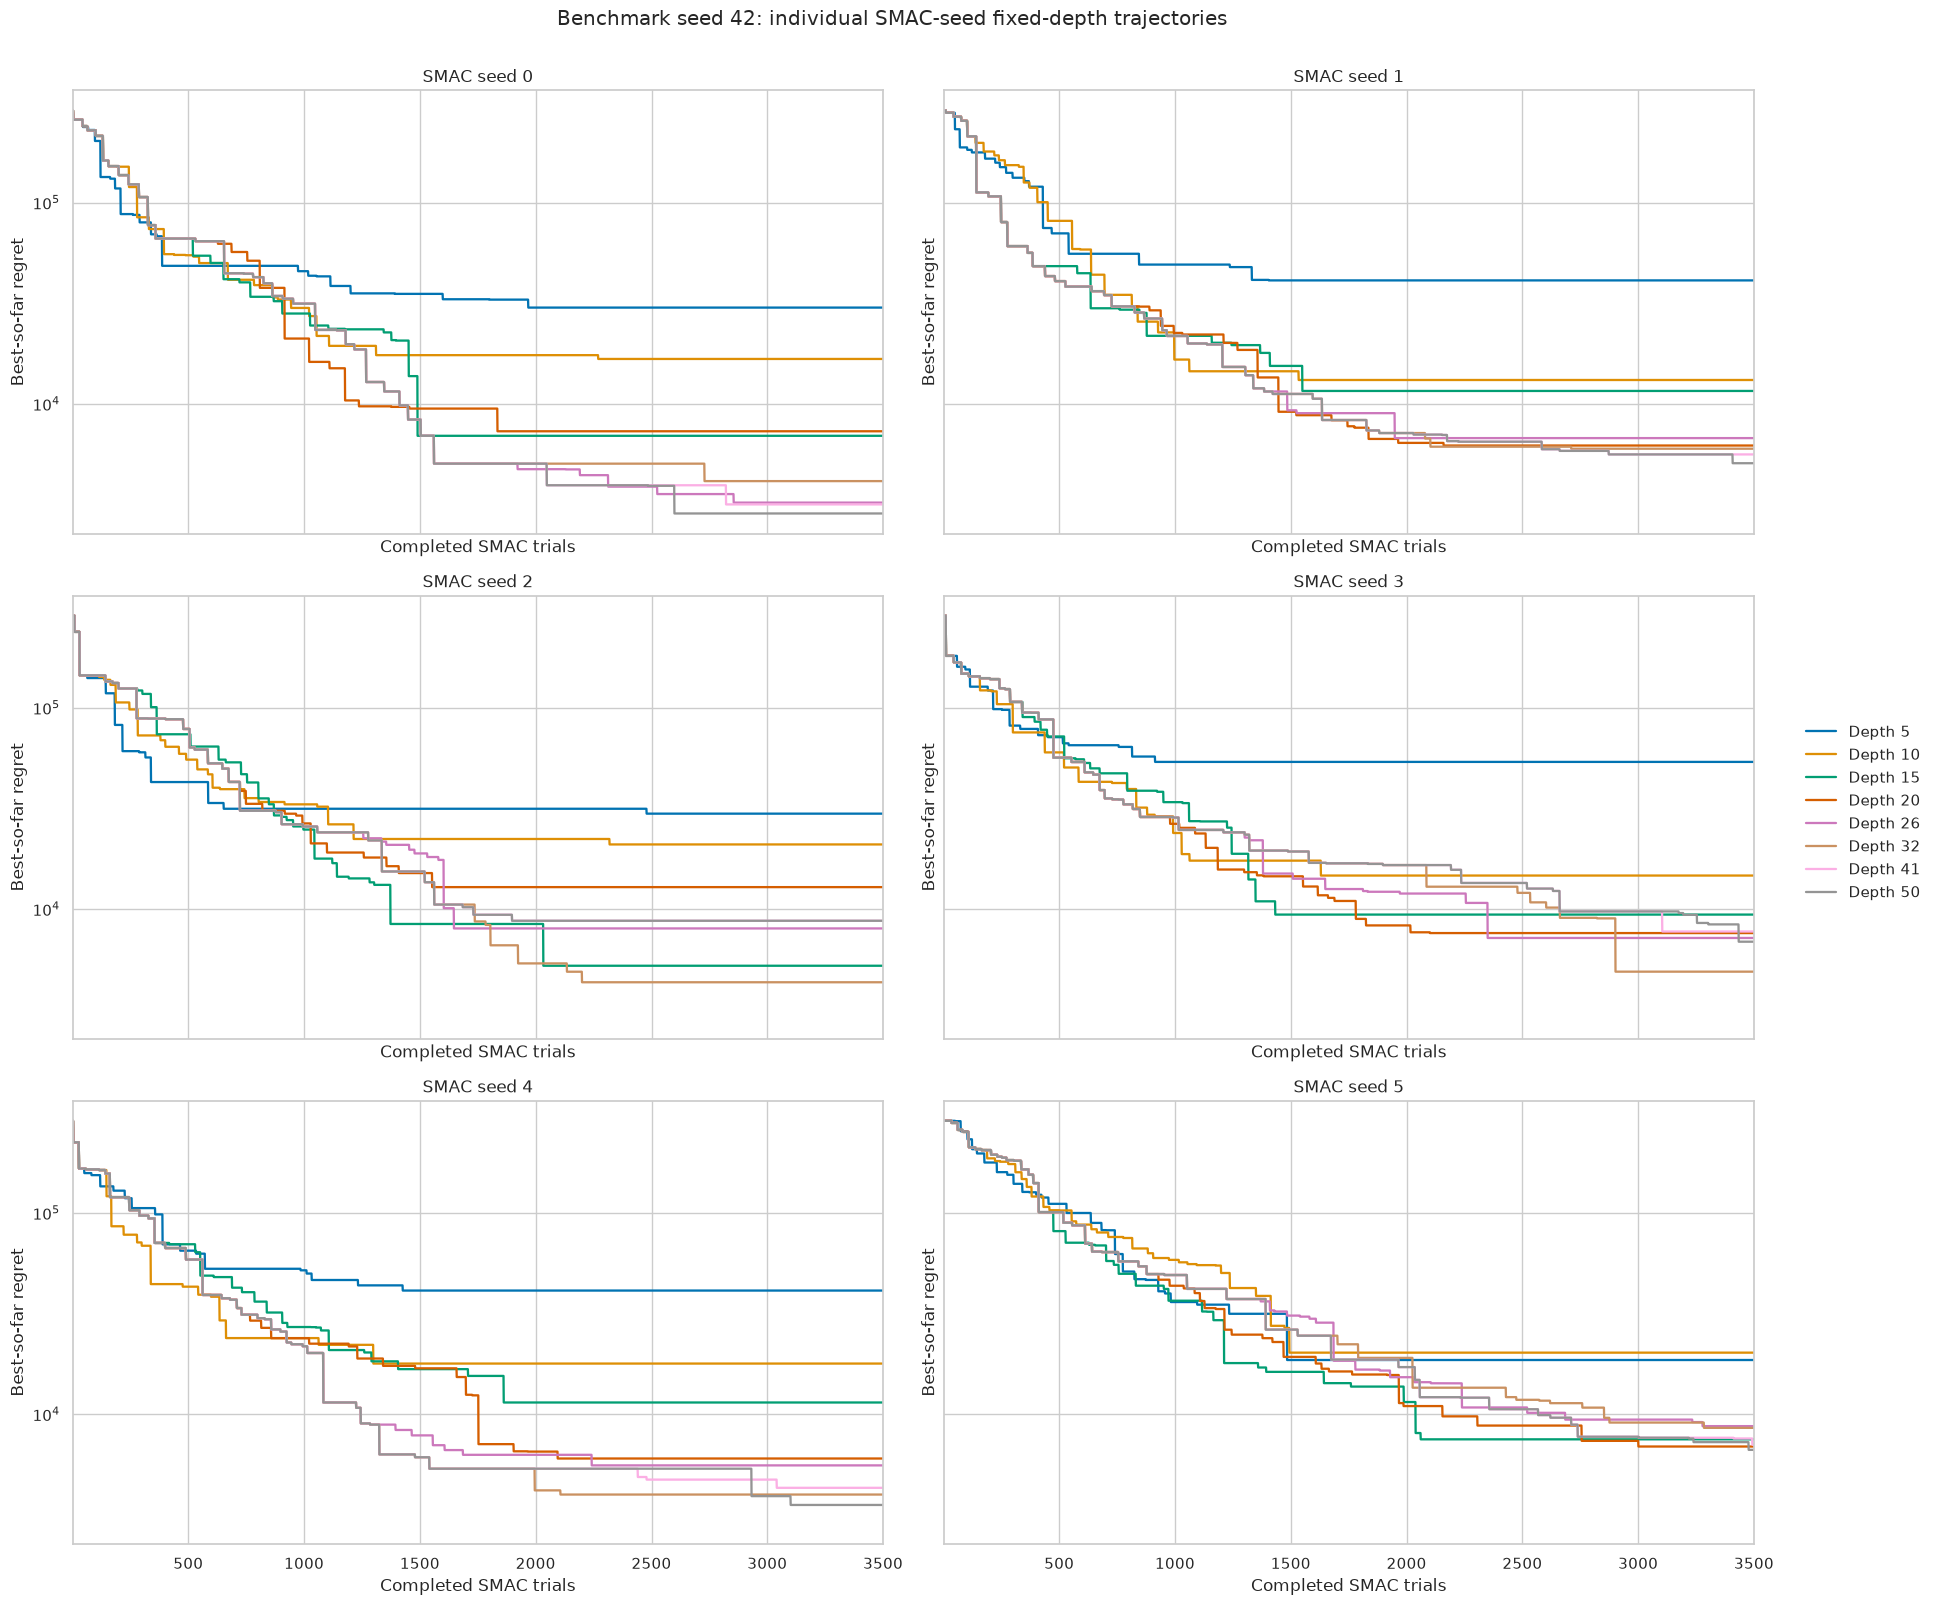

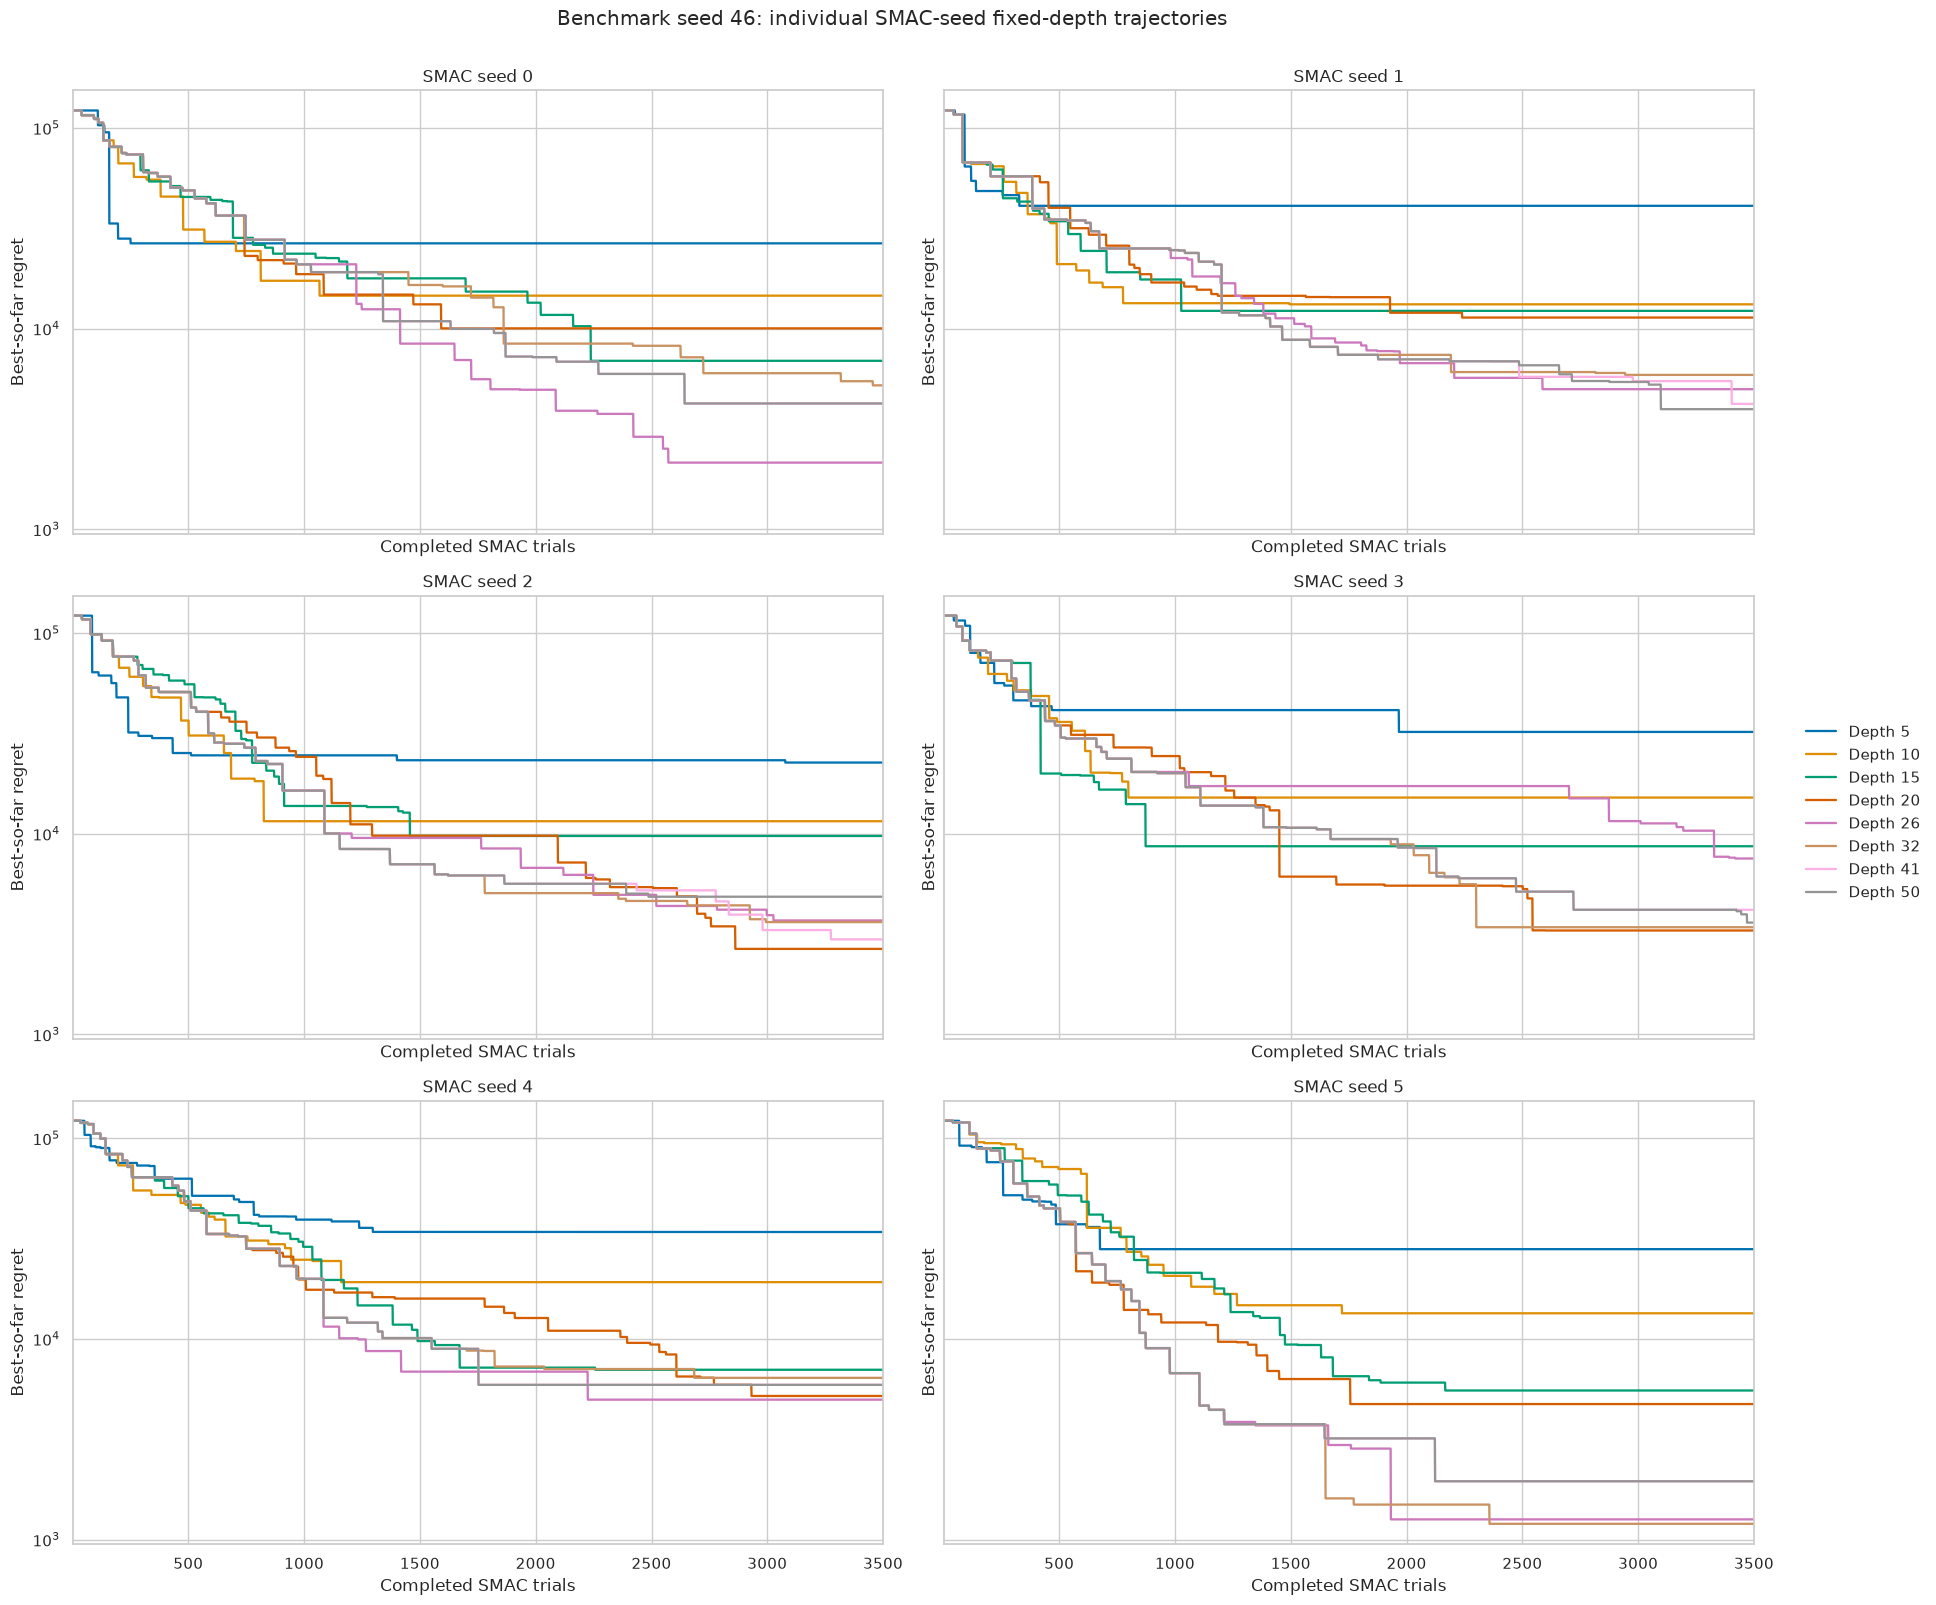

Saved 14 plot files in /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/01_03_individual_smac_sees/plots


In [3]:
positive_values = np.concatenate([trajectory[trajectory > 0] for trajectory in runs['best_regret']])
PLOT_FLOOR = max(float(positive_values.min()) * 0.5, 1e-12)
iterations = np.arange(1, N_TRIALS + 1)
print(f'Log-scale floor: {PLOT_FLOOR:.3g}')

def plot_seed_trajectories(axis, benchmark_seed, smac_seed, *, show_legend=False):
    selected = runs.query('benchmark_seed == @benchmark_seed and smac_seed == @smac_seed')
    for depth in DEPTHS:
        row = selected.loc[selected['depth'].eq(depth)].iloc[0]
        axis.plot(
            iterations,
            np.maximum(row['best_regret'], PLOT_FLOOR),
            color=COLORS[depth],
            linewidth=1.65,
            label=f'Depth {depth}',
        )
    axis.set_yscale('log')
    axis.set_xlim(1, N_TRIALS)
    axis.set_title(f'SMAC seed {smac_seed}')
    axis.set_xlabel('Completed SMAC trials')
    axis.set_ylabel('Best-so-far regret')
    if show_legend:
        axis.legend(frameon=False, ncol=2)

for benchmark_seed in BENCHMARK_SEEDS:
    fig, axes = plt.subplots(3, 2, figsize=(18, 16), sharex=True, sharey=True)
    for axis, smac_seed in zip(axes.ravel(), SMAC_SEEDS):
        plot_seed_trajectories(axis, benchmark_seed, smac_seed)
    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
    fig.suptitle(f'Benchmark seed {benchmark_seed}: individual SMAC-seed fixed-depth trajectories', y=1.002)
    fig.tight_layout()
    output_path = PLOT_DIR / f'benchmark_seed_{benchmark_seed}_all_smac_seeds.png'
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()

    for smac_seed in SMAC_SEEDS:
        fig, axis = plt.subplots(figsize=(11, 7))
        plot_seed_trajectories(axis, benchmark_seed, smac_seed, show_legend=True)
        axis.set_title(f'Benchmark seed {benchmark_seed}, SMAC seed {smac_seed}')
        fig.tight_layout()
        fig.savefig(
            PLOT_DIR / f'benchmark_seed_{benchmark_seed}_smac_seed_{smac_seed}.png',
            dpi=180,
            bbox_inches='tight',
        )
        plt.close(fig)

print(f'Saved 14 plot files in {PLOT_DIR.resolve()}')

## Final values

This compact table helps identify the endpoints represented by the rightmost point of every curve. It is descriptive only: each row is a single SMAC run, not an average across seeds.

In [4]:
final_table = (
    runs.pivot(index=['benchmark_seed', 'smac_seed'], columns='depth', values='final_best_regret')
    .rename_axis(columns='fixed_depth')
    .sort_index()
)
display(final_table.style.format('{:.6g}').highlight_min(axis=1, color='#b7e4c7'))

# New 7,000-trial experiment: benchmark seed 40

This section analyzes the 56 runs stored directly in this directory. It is intentionally separate from the preceding 3,500-trial comparison because the benchmark seed, SMAC-seed count, fixed-depth set, run length, and data source differ.

The new matrix contains benchmark seed **40**, SMAC seeds **0–6**, and fixed depths **5, 10, 15, 20, 25, 30, 40, 50**.

In [ ]:
LONG_BENCHMARK_SEED = 40
LONG_SMAC_SEEDS = tuple(range(7))
LONG_DEPTHS = (5, 10, 15, 20, 25, 30, 40, 50)
LONG_N_TRIALS = 7000
LONG_OUTPUT = ANALYSIS_DIR / 'smac_output'
LONG_COLORS = dict(zip(LONG_DEPTHS, sns.color_palette('colorblind', n_colors=len(LONG_DEPTHS))))

long_records = []
long_problems = []
for smac_seed in LONG_SMAC_SEEDS:
    for depth in LONG_DEPTHS:
        policy = f'fixed_depth_{depth}'
        path = (LONG_OUTPUT / f'benchmark_seed_{LONG_BENCHMARK_SEED}' / policy / str(smac_seed) / 'trajectory.json')
        try:
            data = json.loads(path.read_text())
            trajectory = np.asarray(data['best_regret'], dtype=float)
        except (OSError, json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
            long_problems.append((smac_seed, depth, str(error), str(path)))
            continue

        checks = {
            'benchmark seed': data.get('benchmark_seed') == LONG_BENCHMARK_SEED,
            'SMAC seed': data.get('smac_seed') == smac_seed,
            'policy': data.get('policy') == policy,
            'reported trials': data.get('n_trials') == LONG_N_TRIALS,
            'trajectory length': len(trajectory) == LONG_N_TRIALS,
            'finite': bool(np.isfinite(trajectory).all()),
            'monotone': bool(np.all(np.diff(trajectory) <= 1e-10)),
        }
        failed = [name for name, passed in checks.items() if not passed]
        if failed:
            long_problems.append((smac_seed, depth, ', '.join(failed), str(path)))
            continue

        long_records.append({
            'benchmark_seed': LONG_BENCHMARK_SEED,
            'smac_seed': smac_seed,
            'depth': depth,
            'best_regret': trajectory,
            'final_best_regret': float(trajectory[-1]),
            'path': path,
        })

long_runs = pd.DataFrame(long_records)
long_expected = len(LONG_SMAC_SEEDS) * len(LONG_DEPTHS)
print(f'Validated {len(long_runs)} / {long_expected} requested 7,000-trial trajectories.')
if long_problems:
    display(pd.DataFrame(long_problems, columns=['smac_seed', 'depth', 'problem', 'path']))
assert len(long_runs) == long_expected, 'Some 7,000-trial trajectories are missing or invalid.'
assert long_runs.groupby('smac_seed').size().eq(len(LONG_DEPTHS)).all()
display(long_runs.groupby(['smac_seed']).size().rename('valid_depth_runs').to_frame())

## Individual SMAC-seed trajectories through trial 7,000

Each panel is one independent SMAC seed. All eight fixed-depth trajectories use the same landscape and axes. Separate full-size panel files and the combined overview are saved in `plots/`.

In [ ]:
long_positive = np.concatenate([trajectory[trajectory > 0] for trajectory in long_runs['best_regret']])
LONG_PLOT_FLOOR = max(float(long_positive.min()) * 0.5, 1e-12)
long_iterations = np.arange(1, LONG_N_TRIALS + 1)
print(f'7,000-trial log-scale floor: {LONG_PLOT_FLOOR:.3g}')

def plot_long_seed(axis, smac_seed, *, show_legend=False):
    selected = long_runs.query('smac_seed == @smac_seed')
    for depth in LONG_DEPTHS:
        row = selected.loc[selected['depth'].eq(depth)].iloc[0]
        axis.plot(
            long_iterations,
            np.maximum(row['best_regret'], LONG_PLOT_FLOOR),
            color=LONG_COLORS[depth],
            linewidth=1.65,
            label=f'Depth {depth}',
        )
    axis.set_yscale('log')
    axis.set_xlim(1, LONG_N_TRIALS)
    axis.set_title(f'SMAC seed {smac_seed}')
    axis.set_xlabel('Completed SMAC trials')
    axis.set_ylabel('Best-so-far regret')
    if show_legend:
        axis.legend(frameon=False, ncol=2)

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True, sharey=True)
for axis, smac_seed in zip(axes.ravel(), LONG_SMAC_SEEDS):
    plot_long_seed(axis, smac_seed)
axes.ravel()[-1].axis('off')
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.suptitle('Benchmark seed 40: individual SMAC-seed trajectories through 7,000 trials', y=1.002)
fig.tight_layout()
long_overview_path = PLOT_DIR / 'benchmark_seed_40_7000_all_smac_seeds.png'
fig.savefig(long_overview_path, dpi=180, bbox_inches='tight')
plt.show()

for smac_seed in LONG_SMAC_SEEDS:
    fig, axis = plt.subplots(figsize=(11, 7))
    plot_long_seed(axis, smac_seed, show_legend=True)
    axis.set_title(f'Benchmark seed 40, SMAC seed {smac_seed}: 7,000 trials')
    fig.tight_layout()
    fig.savefig(
        PLOT_DIR / f'benchmark_seed_40_smac_seed_{smac_seed}_7000.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.close(fig)
print(f'Saved the 7,000-trial overview and {len(LONG_SMAC_SEEDS)} individual plots.')

![Benchmark seed 40 individual SMAC-seed trajectories through 7,000 trials](plots/benchmark_seed_40_7000_all_smac_seeds.png)

## Final 7,000-trial values

Green highlights the lowest final best-so-far regret within each individual SMAC seed.

In [ ]:
long_final_table = (
    long_runs.pivot(index='smac_seed', columns='depth', values='final_best_regret')
    .reindex(index=LONG_SMAC_SEEDS, columns=LONG_DEPTHS)
    .rename_axis(columns='fixed_depth')
)
display(long_final_table.style.format('{:.6g}').highlight_min(axis=1, color='#b7e4c7'))